In [ ]:
"""
=============================================================================
EBOLA SEIFRD — DEFENSIBLE CALIBRATION
  Data used : confirmed cases only  +  confirmed deaths only
  Reason    : suspected cases reflect contact-tracing list size (capacity-
              dependent), not transmission dynamics. Suspected deaths on
              day 1 pre-date any confirmed case — likely all-cause mortality
              in a monitored population. Using noisy proxies biases beta.

  Model     : SEIFRD (Legrand et al. 2007 structure)
  Optimizer : Differential Evolution  (global, gradient-free)
  Loss      : Poisson NLL on daily NEW counts (not cumulative)
  Uncertainty: 200-replicate parametric bootstrap → 95% CI ribbons
=============================================================================
"""

# ── 0. IMPORTS ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, brentq
from datetime import datetime, timedelta
import warnings, os
warnings.filterwarnings("ignore")

np.random.seed(42)


# ══════════════════════════════════════════════════════════════════════════
# 1.  DATA
# ══════════════════════════════════════════════════════════════════════════

raw = {
    "date": ["16/05/2026","17/05/2026","18/05/2026","19/05/2026",
             "20/05/2026","21/05/2026","22/05/2026","23/05/2026",
             "24/05/2026","25/05/2026","26/05/2026"],
    "cum_confirmed": [np.nan, np.nan,  8, 35,  50,  65,  80,  96, 108, 112, 112],
    "cum_conf_dead": [np.nan, np.nan,  3,  4,   5,   7,   9,  10,  11,  11,  13],
}

df = pd.DataFrame(raw)
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")
df["cum_confirmed"] = df["cum_confirmed"].ffill().fillna(0)
df["cum_conf_dead"] = df["cum_conf_dead"].ffill().fillna(0)

df["new_cases"]  = df["cum_confirmed"].diff().fillna(df["cum_confirmed"]).clip(lower=0)
df["new_deaths"] = df["cum_conf_dead"].diff().fillna(df["cum_conf_dead"]).clip(lower=0)

obs_cases  = df["new_cases"].values.copy()
obs_deaths = df["new_deaths"].values.copy()
obs_dates  = df["date"].tolist()
n_days     = len(df)
DATA_START = df["date"].iloc[0]

print("=" * 60)
print("DATA USED FOR CALIBRATION")
print(df[["date","new_cases","new_deaths"]].to_string(index=False))
print("=" * 60)



DATA USED FOR CALIBRATION
      date  new_cases  new_deaths
2026-05-16        0.0         0.0
2026-05-17        0.0         0.0
2026-05-18        8.0         3.0
2026-05-19       27.0         1.0
2026-05-20       15.0         1.0
2026-05-21       15.0         2.0
2026-05-22       15.0         2.0
2026-05-23       16.0         1.0
2026-05-24       12.0         1.0
2026-05-25        4.0         0.0
2026-05-26        0.0         2.0


In [3]:

# ══════════════════════════════════════════════════════════════════════════
# 2.  MODEL
# ══════════════════════════════════════════════════════════════════════════

N = 1500000   # at-risk population (contacts listed ≈ 2000, coverage ~40%)

class SEIFRD:
    """
    S → E → I → R   (survivors)
              I → F → D_safe  (deaths via safe burial)
              I → D_direct    (deaths bypassing F)

    Parameters
    ----------
    betaI  : transmission from I (living infectious)
    betaF  : transmission from F (corpse / unsafe burial window)
    alpha  : 1 / incubation period
    gamma_i: 1 / infectious period, survivors
    gamma_d: 1 / infectious period, fatal cases
    delta1 : CFR — fraction of I that die
    teta1  : fraction of deaths entering F (unsafe burial)
    gamma_f: 1 / duration corpse remains infectious
    """
    def __init__(self, betaI, betaF, alpha, gamma_i, gamma_d,
                 delta1, teta1, gamma_f):
        self.p = (betaI, betaF, alpha, gamma_i, gamma_d, delta1, teta1, gamma_f)
        (self.betaI, self.betaF, self.alpha, self.gamma_i,
         self.gamma_d, self.delta1, self.teta1, self.gamma_f) = self.p

    def __call__(self, t, y):
        S, E, I, F, R, D = y
        betaI, betaF, alpha, gamma_i, gamma_d, delta1, teta1, gamma_f = self.p
        lam = (betaI * I + betaF * F) * S / N
        return [
            -lam,
            lam  - alpha * E,
            alpha * E - (gamma_i*(1-delta1) + gamma_d*delta1) * I,
            gamma_d * delta1 * teta1 * I  - gamma_f * F,
            gamma_i * (1-delta1) * I,
            gamma_d * delta1 * (1-teta1) * I  + gamma_f * F
        ]

    def run(self, t_span, y0, t_eval):
        sol = solve_ivp(self, t_span, y0, method="RK45",
                        t_eval=t_eval, rtol=1e-8, atol=1e-10)
        return sol if sol.success else None

    # ── observables ──────────────────────────────────────────────────────
    def incidence(self, sol):
        """Daily new cases  =  alpha * E(t)"""
        return self.alpha * sol.y[1]

    def new_deaths(self, sol):
        """Daily new deaths  =  dD/dt"""
        return (self.gamma_d * self.delta1 * (1-self.teta1) * sol.y[2]
                + self.gamma_f * sol.y[3])

    def R0(self):
        ge = self.gamma_i*(1-self.delta1) + self.gamma_d*self.delta1
        return (self.betaI/ge
                + self.betaF*self.gamma_d*self.delta1*self.teta1
                  / (self.gamma_f * ge))

    def doubling_time(self):
        """Approximate early-growth doubling time (days)."""
        # Growth rate r ≈ betaI - gamma_eff  for simple SIR analogy;
        # we estimate numerically from the fit trajectory.
        return None   # computed post-hoc below



In [4]:

# ══════════════════════════════════════════════════════════════════════════
# 3.  PARAMETER BOUNDS  (Ebola literature)
# ══════════════════════════════════════════════════════════════════════════
#
#  betaI  0.05–0.40  Legrand (2007), Althaus (2014)
#  betaF  0.10–0.80  funeral transmission dominant in Ebola
#  alpha  1/21–1/2   incubation 2–21 d (WHO); mean 8–10 d
#  gamma_i 1/21–1/5  survivors shed 5–10 d
#  gamma_d 1/14–1/3  fatal cases: 3–7 d symptom-to-death
#  delta1 0.25–0.90  CFR range all documented outbreaks
#  teta1  0.10–0.80  unsafe burial fraction; context-dependent
#  gamma_f 1/3–1.0   corpse infectious 1–3 days
#  log_E0  0–2.5     E0 ∈ [1, 12]  (biologically plausible onset)
#  log_I0  0–2.5     I0 ∈ [1, 12]

BOUNDS = [
    (0.05, 0.40),   # betaI
    (0.10, 0.80),   # betaF
    (1/21, 1/2 ),   # alpha
    (1/21, 1/5 ),   # gamma_i
    (1/14, 1/3 ),   # gamma_d
    (0.25, 0.90),   # delta1
    (0.10, 0.80),   # teta1
    (1/3,  1.00),   # gamma_f
    (0.0,  2.5 ),   # log_E0
    (0.0,  2.5 ),   # log_I0
]


In [5]:


# ══════════════════════════════════════════════════════════════════════════
# 4.  OBJECTIVE  —  Poisson NLL on daily NEW confirmed cases + deaths
# ══════════════════════════════════════════════════════════════════════════

def pnll(obs, pred):
    """Poisson negative log-likelihood. Correct loss for count data."""
    pred = np.maximum(np.asarray(pred, float), 1e-9)
    obs  = np.asarray(obs, float)
    return -np.sum(obs * np.log(pred) - pred)


def build_model(params):
    betaI,betaF,alpha,gamma_i,gamma_d,delta1,teta1,gamma_f,le0,li0 = params
    E0 = np.exp(le0); I0 = np.exp(li0); S0 = N - E0 - I0
    return (SEIFRD(betaI,betaF,alpha,gamma_i,gamma_d,delta1,teta1,gamma_f),
            [S0, E0, I0, 0., 0., 0.], S0 > 0)


def objective(params):
    model, y0, ok = build_model(params)
    if not ok:
        return 1e12
    t_eval = np.arange(n_days, dtype=float)
    sol = model.run((0., float(n_days-1)), y0, t_eval)
    if sol is None:
        return 1e12
    nll_c = pnll(obs_cases,  model.incidence(sol))
    nll_d = pnll(obs_deaths, model.new_deaths(sol))
    return nll_c + nll_d



In [8]:

# ══════════════════════════════════════════════════════════════════════════
# 5.  CALIBRATION
# ══════════════════════════════════════════════════════════════════════════

print("\nRunning Differential Evolution …")
result = differential_evolution(
    objective, BOUNDS,
    seed=42, maxiter=3000, popsize=20,
    tol=1e-10, mutation=(0.5, 1.5), recombination=0.8,
    polish=True, disp=True, workers=-1
)
print(f"\nDone.  NLL = {result.fun:.4f}")

# unpack best-fit
(betaI_hat, betaF_hat, alpha_hat, gamma_i_hat, gamma_d_hat,
 delta1_hat, teta1_hat, gamma_f_hat, le0_hat, li0_hat) = result.x

E0_hat = np.exp(le0_hat)
I0_hat = np.exp(li0_hat)
S0_hat = N - E0_hat - I0_hat

model_hat = SEIFRD(betaI_hat, betaF_hat, alpha_hat, gamma_i_hat,
                   gamma_d_hat, delta1_hat, teta1_hat, gamma_f_hat)
R0_hat = model_hat.R0()

print("\n" + "=" * 60)
print("BEST-FIT PARAMETERS")
print("=" * 60)
print(f"  betaI        = {betaI_hat:.4f}  (living contact rate)")
print(f"  betaF        = {betaF_hat:.4f}  (funeral contact rate)")
print(f"  alpha        = {alpha_hat:.4f}  → incubation {1/alpha_hat:.1f} d")
print(f"  gamma_i      = {gamma_i_hat:.4f}  → survivor infectious {1/gamma_i_hat:.1f} d")
print(f"  gamma_d      = {gamma_d_hat:.4f}  → fatal infectious {1/gamma_d_hat:.1f} d")
print(f"  delta1 (CFR) = {delta1_hat:.4f}  ({delta1_hat*100:.1f} %)")
print(f"  teta1        = {teta1_hat:.4f}  (unsafe burial fraction)")
print(f"  gamma_f      = {gamma_f_hat:.4f}  → corpse window {1/gamma_f_hat:.1f} d")
print(f"  E0           = {E0_hat:.2f}")
print(f"  I0           = {I0_hat:.2f}")
print(f"  R0           = {R0_hat:.3f}")
print("=" * 60)




Running Differential Evolution …
differential_evolution step 1: f(x)= -117.02264150291887
differential_evolution step 2: f(x)= -117.02264150291887
differential_evolution step 3: f(x)= -118.83711241744543
differential_evolution step 4: f(x)= -120.4172033770232
differential_evolution step 5: f(x)= -120.4172033770232
differential_evolution step 6: f(x)= -120.61576813190948
differential_evolution step 7: f(x)= -121.72918983771807
differential_evolution step 8: f(x)= -121.72918983771807
differential_evolution step 9: f(x)= -121.72918983771807
differential_evolution step 10: f(x)= -123.76274359721862
differential_evolution step 11: f(x)= -123.76274359721862
differential_evolution step 12: f(x)= -124.0261535686513
differential_evolution step 13: f(x)= -124.0261535686513
differential_evolution step 14: f(x)= -124.20810215169425
differential_evolution step 15: f(x)= -124.5254850797815
differential_evolution step 16: f(x)= -124.5254850797815
differential_evolution step 17: f(x)= -125.6041725567

In [9]:

# ══════════════════════════════════════════════════════════════════════════
# 6.  FIT TRAJECTORIES ON DATA WINDOW
# ══════════════════════════════════════════════════════════════════════════

t_data = np.arange(n_days, dtype=float)
sol_fit = model_hat.run(
    (0., float(n_days-1)),
    [S0_hat, E0_hat, I0_hat, 0., 0., 0.],
    t_data
)
fit_cases  = model_hat.incidence(sol_fit)
fit_deaths = model_hat.new_deaths(sol_fit)
fit_cum_c  = np.cumsum(fit_cases)
fit_cum_d  = np.cumsum(fit_deaths)



In [10]:

# ══════════════════════════════════════════════════════════════════════════
# 7.  t0 ESTIMATION  (forward shooting — numerically stable)
# ══════════════════════════════════════════════════════════════════════════
#
# Run the ODE forward from I=1 until I(T) = I0_hat.
# T days = how far before DATA_START the index case occurred.

def I_at_T(T):
    if T <= 0:
        return 1.0
    sol = solve_ivp(model_hat, (0, T),
                    [N-1., 0., 1., 0., 0., 0.],
                    method="RK45", t_eval=[T],
                    rtol=1e-8, atol=1e-10)
    return float(sol.y[2, -1])

f_lo = I_at_T(1)   - I0_hat
f_hi = I_at_T(120) - I0_hat

if f_lo * f_hi < 0:
    days_before = brentq(lambda T: I_at_T(T) - I0_hat, 1, 120, xtol=0.05)
elif f_lo > 0:
    days_before = 0.0
else:
    days_before = 120.0

t0_date = DATA_START - timedelta(days=float(days_before))
print(f"\nEstimated t0  : {t0_date.strftime('%d %B %Y')}")
print(f"Days before first data point: {days_before:.1f}")




Estimated t0  : 19 April 2026
Days before first data point: 26.5


In [11]:

# ══════════════════════════════════════════════════════════════════════════
# 8.  DOUBLING TIME  (from early growth of cumulative cases)
# ══════════════════════════════════════════════════════════════════════════
#
# Fit log(cum_cases) ~ r*t on the first segment where cases are growing.
# doubling time = log(2) / r

def compute_doubling_time(model, y0, n=30):
    t_ev = np.arange(n, dtype=float)
    sol  = model.run((0., float(n-1)), y0, t_ev)
    cum  = np.cumsum(model.incidence(sol))
    # use days 2–15 (exponential phase, avoid zeros)
    mask = (t_ev >= 2) & (cum > 0)
    if mask.sum() < 3:
        return np.nan
    coeffs = np.polyfit(t_ev[mask], np.log(cum[mask]), 1)
    r = coeffs[0]
    return np.log(2) / r if r > 0 else np.nan

doubling_time = compute_doubling_time(
    model_hat,
    [S0_hat, E0_hat, I0_hat, 0., 0., 0.]
)
print(f"Doubling time : {doubling_time:.1f} days  (early exponential phase)")


Doubling time : 4.9 days  (early exponential phase)


In [12]:


# ══════════════════════════════════════════════════════════════════════════
# 9.  90-DAY PROJECTION
# ══════════════════════════════════════════════════════════════════════════

N_PROJ  = 90
t_fine  = np.linspace(0, N_PROJ, N_PROJ*4 + 1)
sol_proj = model_hat.run(
    (0., N_PROJ),
    [S0_hat, E0_hat, I0_hat, 0., 0., 0.],
    t_fine
)
S_p,E_p,I_p,F_p,R_p,D_p = sol_proj.y
inc_p   = model_hat.incidence(sol_proj)
dead_p  = model_hat.new_deaths(sol_proj)
dt      = t_fine[1] - t_fine[0]
cum_c_p = np.cumsum(inc_p)  * dt
cum_d_p = np.cumsum(dead_p) * dt
proj_dates = [DATA_START + timedelta(days=float(d)) for d in t_fine]

peak_I_idx  = int(np.argmax(I_p))
peak_I_date = proj_dates[peak_I_idx]
peak_I_val  = I_p[peak_I_idx]

peak_inc_idx  = int(np.argmax(inc_p))
peak_inc_date = proj_dates[peak_inc_idx]
peak_inc_val  = inc_p[peak_inc_idx]

# When does the doubling of cumulative cases occur?
# Find t* such that cum_cases(t*) = 2 * cum_cases at last observed day
baseline_cum = float(df["cum_confirmed"].iloc[-1])
doubled_cum  = 2 * baseline_cum
t_double_idx = np.where(cum_c_p >= doubled_cum)[0]
if len(t_double_idx) > 0:
    t_double_days = t_fine[t_double_idx[0]]
    double_date   = DATA_START + timedelta(days=float(t_double_days))
else:
    double_date   = None

print(f"\nPeak infectious load : {peak_I_val:.0f} individuals  on  {peak_I_date.strftime('%d %b %Y')}")
print(f"Peak daily incidence : {peak_inc_val:.1f} cases/day    on  {peak_inc_date.strftime('%d %b %Y')}")
if double_date:
    print(f"Cumulative cases double ({baseline_cum:.0f}→{doubled_cum:.0f})  on  {double_date.strftime('%d %b %Y')}")
print(f"Projected cum. cases  day 30 : {np.interp(30, t_fine, cum_c_p):.0f}")
print(f"Projected cum. deaths day 30 : {np.interp(30, t_fine, cum_d_p):.0f}")
print(f"Projected cum. cases  day 60 : {np.interp(60, t_fine, cum_c_p):.0f}")
print(f"Projected cum. deaths day 60 : {np.interp(60, t_fine, cum_d_p):.0f}")




Peak infectious load : 120988 individuals  on  14 Aug 2026
Peak daily incidence : 29753.3 cases/day    on  14 Aug 2026
Cumulative cases double (112→224)  on  01 Jun 2026
Projected cum. cases  day 30 : 1138
Projected cum. deaths day 30 : 204
Projected cum. cases  day 60 : 31571
Projected cum. deaths day 60 : 5731


In [15]:

# ══════════════════════════════════════════════════════════════════════════
# 10.  BOOTSTRAP 95% CONFIDENCE INTERVALS
# ══════════════════════════════════════════════════════════════════════════
#
# Parametric bootstrap:
#   1. From best-fit model, draw Poisson-distributed synthetic observations.
#   2. Re-calibrate (short DE) on each synthetic dataset.
#   3. Project forward and collect trajectories.
#   4. Report 2.5th–97.5th percentile ribbon.
#
# 200 replicates is sufficient for 95% CI at this sample size.

N_BOOT = 50
print(f"\nBootstrap ({N_BOOT} replicates) …")

boot_inc   = np.zeros((N_BOOT, len(t_fine)))
boot_dead  = np.zeros((N_BOOT, len(t_fine)))
boot_cumC  = np.zeros((N_BOOT, len(t_fine)))
boot_cumD  = np.zeros((N_BOOT, len(t_fine)))
boot_R0    = np.zeros(N_BOOT)

BOUNDS_BOOT = BOUNDS   # same bounds

for b in range(N_BOOT):
    # draw synthetic data from Poisson(best-fit prediction)
    syn_cases  = np.random.poisson(np.maximum(fit_cases,  1e-6)).astype(float)
    syn_deaths = np.random.poisson(np.maximum(fit_deaths, 1e-6)).astype(float)

    def obj_boot(params):
        m, y0b, ok = build_model(params)
        if not ok:
            return 1e12
        s = m.run((0., float(n_days-1)), y0b, t_data)
        if s is None:
            return 1e12
        return pnll(syn_cases,  m.incidence(s)) + \
               pnll(syn_deaths, m.new_deaths(s))

    res_b = differential_evolution(
        obj_boot, BOUNDS_BOOT,
        seed=b, maxiter=400, popsize=12,
        tol=1e-7, polish=True, disp=False, workers=-1
    )

    mb, y0b, ok = build_model(res_b.x)
    if not ok:
        continue
    sb = mb.run((0., N_PROJ), y0b, t_fine)
    if sb is None:
        continue

    boot_inc[b]  = mb.incidence(sb)
    boot_dead[b] = mb.new_deaths(sb)
    boot_cumC[b] = np.cumsum(mb.incidence(sb))  * dt
    boot_cumD[b] = np.cumsum(mb.new_deaths(sb)) * dt
    boot_R0[b]   = mb.R0()

    if (b+1) % 20 == 0:
        print(f"  {b+1}/{N_BOOT}")

# percentiles
def ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, lo, axis=0), np.percentile(arr, hi, axis=0)

inc_lo,  inc_hi  = ci(boot_inc)
dead_lo, dead_hi = ci(boot_dead)
cumC_lo, cumC_hi = ci(boot_cumC)
cumD_lo, cumD_hi = ci(boot_cumD)
R0_lo,   R0_hi   = np.percentile(boot_R0[boot_R0>0], [2.5, 97.5])
print(f"\nR0 = {R0_hat:.2f}  95% CI [{R0_lo:.2f}, {R0_hi:.2f}]")



Bootstrap (50 replicates) …
  20/50
  40/50

R0 = 1.86  95% CI [1.67, 5.39]


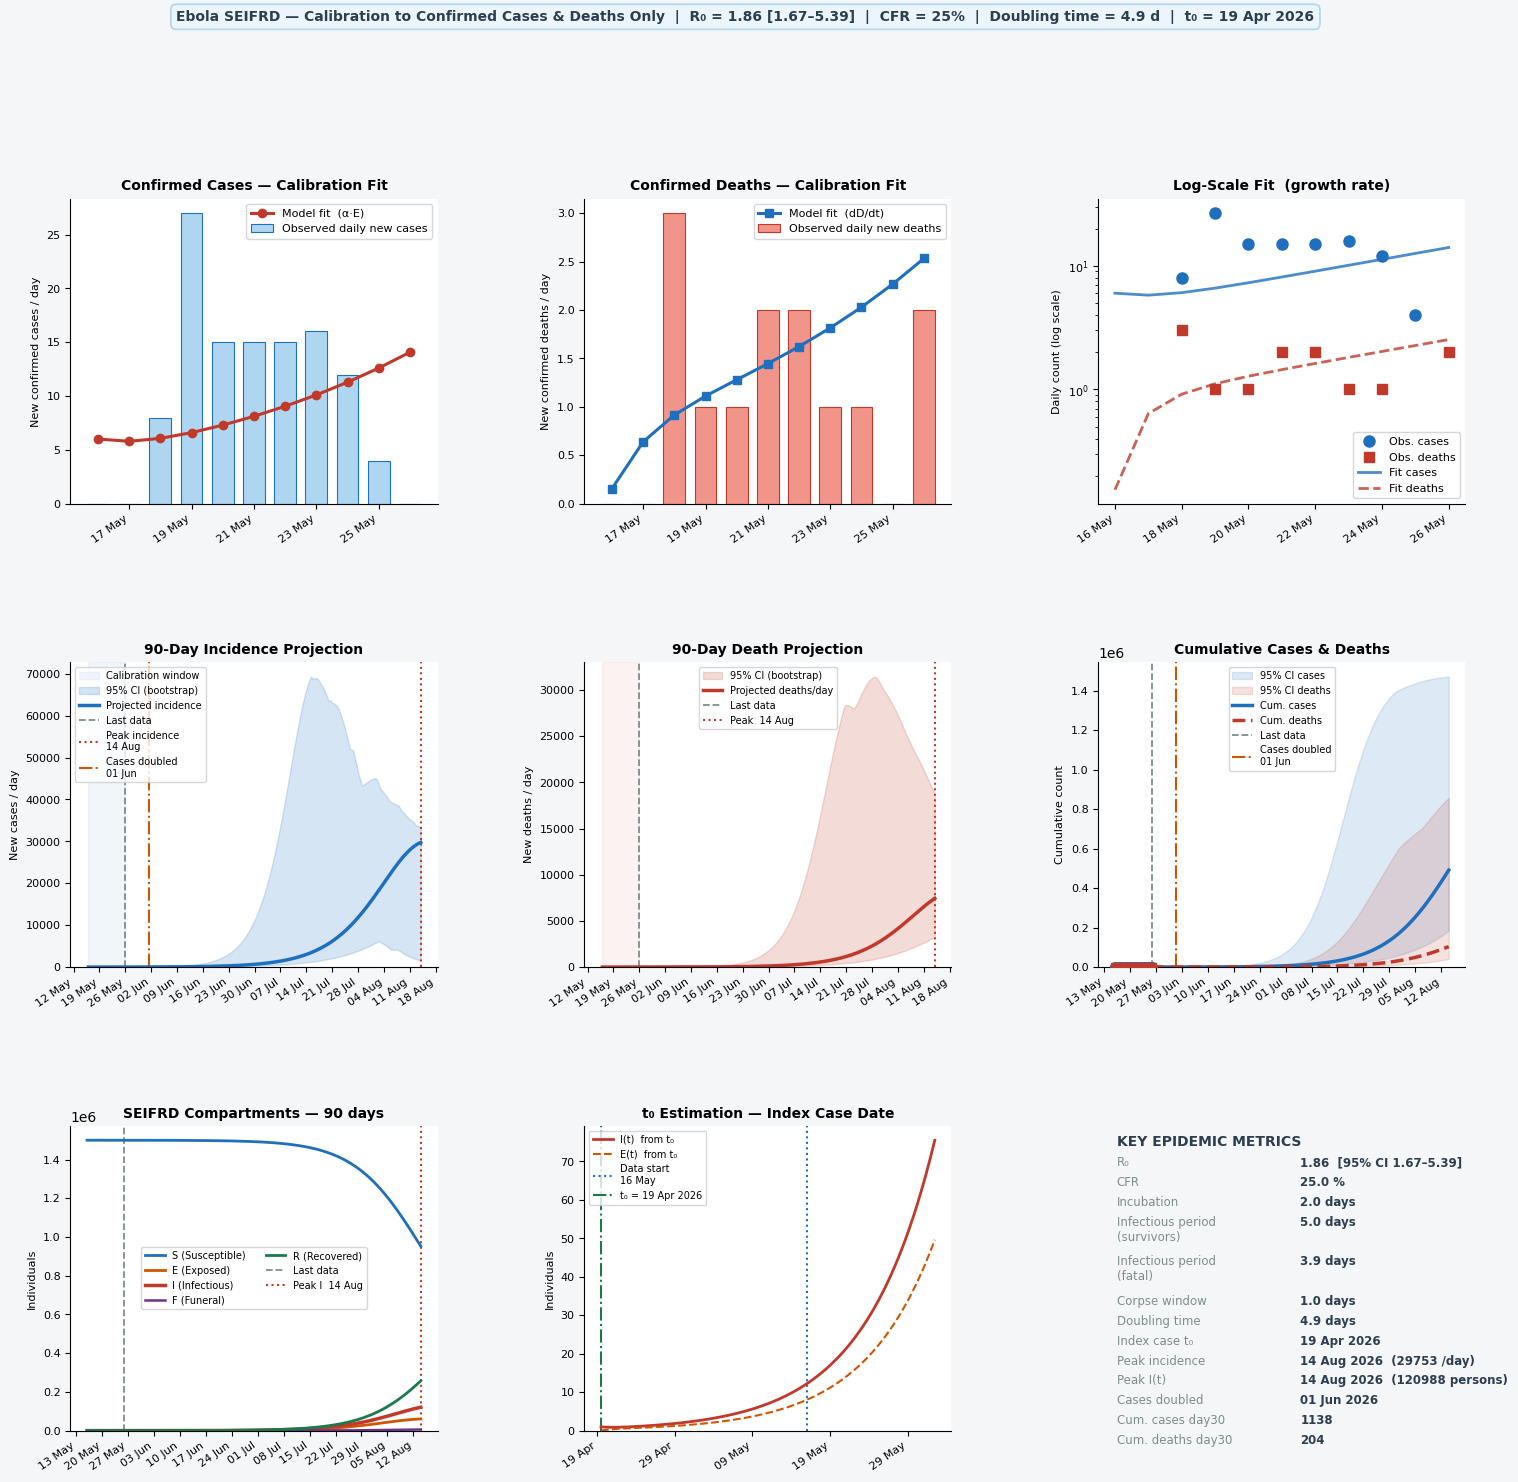


Figure saved to: /home/moez/ebola_calibration_final.png


In [22]:


# ══════════════════════════════════════════════════════════════════════════
# 11.  PLOTS
# ══════════════════════════════════════════════════════════════════════════

BLUE   = '#1F6FBF';  LBLUE  = '#AED6F1'
RED    = '#C0392B';  LRED   = '#F1948A'
GREEN  = '#1A7A4A';  LGREEN = '#A9DFBF'
ORANGE = '#D35400';  GRAY   = '#7F8C8D'
PURPLE = '#6C3483'

def style(ax, interval=7):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=interval))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

def vline(ax, date, label=None, color=GRAY, ls='--', lw=1.3):
    ax.axvline(date, color=color, lw=lw, ls=ls,
               label=label, zorder=1)

last_obs = obs_dates[-1]

fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor('#F4F6F7')
gs  = fig.add_gridspec(3, 3, hspace=0.52, wspace=0.40)

# ── [0,0]  CONFIRMED CASES FIT ─────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.bar(obs_dates, obs_cases,
       color=LBLUE, edgecolor=BLUE, lw=0.8, width=0.7,
       label='Observed daily new cases', zorder=2)
ax.plot(obs_dates, fit_cases, 'o-', color=RED, lw=2.2, ms=6,
        label='Model fit  (α·E)', zorder=3)
ax.set_title('Confirmed Cases — Calibration Fit',
             fontsize=10, fontweight='bold')
ax.set_ylabel('New confirmed cases / day', fontsize=8)
ax.legend(fontsize=8); ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
style(ax, interval=2)

# ── [0,1]  CONFIRMED DEATHS FIT ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.bar(obs_dates, obs_deaths,
       color=LRED, edgecolor=RED, lw=0.8, width=0.7,
       label='Observed daily new deaths', zorder=2)
ax.plot(obs_dates, fit_deaths, 's-', color=BLUE, lw=2.2, ms=6,
        label='Model fit  (dD/dt)', zorder=3)
ax.set_title('Confirmed Deaths — Calibration Fit',
             fontsize=10, fontweight='bold')
ax.set_ylabel('New confirmed deaths / day', fontsize=8)
ax.legend(fontsize=8); ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
style(ax, interval=2)

# ── [0,2]  LOG-SCALE FIT (growth rate check) ───────────────────────────
ax = fig.add_subplot(gs[0, 2])
mc = obs_cases  > 0
md = obs_deaths > 0
ax.semilogy(np.array(obs_dates)[mc], obs_cases[mc],
            'o', color=BLUE, ms=8, label='Obs. cases', zorder=3)
ax.semilogy(np.array(obs_dates)[md], obs_deaths[md],
            's', color=RED,  ms=7, label='Obs. deaths', zorder=3)
ax.semilogy(obs_dates, np.maximum(fit_cases,  0.01),
            '-',  color=BLUE, lw=2, alpha=0.8, label='Fit cases')
ax.semilogy(obs_dates, np.maximum(fit_deaths, 0.001),
            '--', color=RED,  lw=2, alpha=0.8, label='Fit deaths')
ax.set_title('Log-Scale Fit  (growth rate)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Daily count (log scale)', fontsize=8)
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
style(ax, interval=2)

# ── [1,0]  90-DAY INCIDENCE PROJECTION  with 95% CI ───────────────────
ax = fig.add_subplot(gs[1, 0])
ax.axvspan(DATA_START, last_obs, alpha=0.06, color=BLUE,
           label='Calibration window')
ax.fill_between(proj_dates, inc_lo, inc_hi,
                color=BLUE, alpha=0.18, label='95% CI (bootstrap)')
ax.plot(proj_dates, inc_p, '-', color=BLUE, lw=2.5,
        label='Projected incidence')
ax.bar(obs_dates, obs_cases, color=LBLUE, edgecolor=BLUE,
       lw=0.5, width=0.7, zorder=2, alpha=0.9)
vline(ax, last_obs,  'Last data',                  color=GRAY)
vline(ax, peak_inc_date,
      f'Peak incidence\n{peak_inc_date.strftime("%d %b")}',
      color=RED, ls=':', lw=1.5)
if double_date:
    vline(ax, double_date,
          f'Cases doubled\n{double_date.strftime("%d %b")}',
          color=ORANGE, ls='-.', lw=1.5)
ax.set_title('90-Day Incidence Projection', fontsize=10, fontweight='bold')
ax.set_ylabel('New cases / day', fontsize=8)
ax.legend(fontsize=7, loc='upper left'); ax.set_ylim(bottom=0)
style(ax)

# ── [1,1]  90-DAY DEATH PROJECTION  with 95% CI ───────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.axvspan(DATA_START, last_obs, alpha=0.06, color=RED)
ax.fill_between(proj_dates, dead_lo, dead_hi,
                color=RED, alpha=0.18, label='95% CI (bootstrap)')
ax.plot(proj_dates, dead_p, '-', color=RED, lw=2.5,
        label='Projected deaths/day')
ax.bar(obs_dates, obs_deaths, color=LRED, edgecolor=RED,
       lw=0.5, width=0.7, zorder=2, alpha=0.9)
vline(ax, last_obs, 'Last data', color=GRAY)
vline(ax, peak_inc_date,
      f'Peak  {peak_inc_date.strftime("%d %b")}',
      color=RED, ls=':', lw=1.5)
ax.set_title('90-Day Death Projection', fontsize=10, fontweight='bold')
ax.set_ylabel('New deaths / day', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax)

# ── [1,2]  CUMULATIVE CASES & DEATHS  with 95% CI ─────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.fill_between(proj_dates, cumC_lo, cumC_hi,
                color=BLUE, alpha=0.15, label='95% CI cases')
ax.fill_between(proj_dates, cumD_lo, cumD_hi,
                color=RED,  alpha=0.15, label='95% CI deaths')
ax.plot(proj_dates, cum_c_p, '-',  color=BLUE, lw=2.5, label='Cum. cases')
ax.plot(proj_dates, cum_d_p, '--', color=RED,  lw=2.5, label='Cum. deaths')
ax.plot(obs_dates, df["cum_confirmed"].values,
        'o', color=BLUE, ms=7, zorder=3)
ax.plot(obs_dates, df["cum_conf_dead"].values,
        's', color=RED,  ms=6, zorder=3)
vline(ax, last_obs, 'Last data', color=GRAY)
if double_date:
    vline(ax, double_date,
          f'Cases doubled\n{double_date.strftime("%d %b")}',
          color=ORANGE, ls='-.', lw=1.5)
ax.set_title('Cumulative Cases & Deaths', fontsize=10, fontweight='bold')
ax.set_ylabel('Cumulative count', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax)

# ── [2,0]  ALL COMPARTMENTS ────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
ax.plot(proj_dates, S_p, lw=2,   color=BLUE,   label='S (Susceptible)')
ax.plot(proj_dates, E_p, lw=2,   color=ORANGE, label='E (Exposed)')
ax.plot(proj_dates, I_p, lw=2.5, color=RED,    label='I (Infectious)')
ax.plot(proj_dates, F_p, lw=1.8, color=PURPLE, label='F (Funeral)')
ax.plot(proj_dates, R_p, lw=2,   color=GREEN,  label='R (Recovered)')
vline(ax, last_obs,    'Last data',  color=GRAY)
vline(ax, peak_I_date,
      f'Peak I  {peak_I_date.strftime("%d %b")}',
      color=RED, ls=':', lw=1.5)
ax.set_title('SEIFRD Compartments — 90 days',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Individuals', fontsize=8)
ax.legend(fontsize=7, ncol=2); ax.set_ylim(bottom=0)
style(ax)

# ── [2,1]  t0 TIMELINE ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
T_show = int(np.ceil(days_before)) + n_days + 5
t_t0   = np.linspace(0, T_show, T_show*4+1)
sol_t0 = model_hat.run(
    (0, T_show), [N-1., 0., 1., 0., 0., 0.], t_t0
)
t0_dates = [t0_date + timedelta(days=float(d)) for d in t_t0]
ax.plot(t0_dates, sol_t0.y[2], '-',  color=RED,    lw=2,   label='I(t)  from t₀')
ax.plot(t0_dates, sol_t0.y[1], '--', color=ORANGE, lw=1.5, label='E(t)  from t₀')
vline(ax, DATA_START,
      f'Data start\n{DATA_START.strftime("%d %b")}',
      color=BLUE, ls=':', lw=1.5)
vline(ax, t0_date,
      f't₀ = {t0_date.strftime("%d %b %Y")}',
      color=GREEN, ls='-.', lw=1.5)
ax.set_title('t₀ Estimation — Index Case Date',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Individuals', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax, interval=10)

# ── [2,2]  KEY METRICS SUMMARY TEXT PANEL ──────────────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.axis('off')
ax.set_facecolor('#FDFEFE')

metrics = [
    ("R₀",              f"{R0_hat:.2f}  [95% CI {R0_lo:.2f}–{R0_hi:.2f}]"),
    ("CFR",             f"{delta1_hat*100:.1f} %"),
    ("Incubation",      f"{1/alpha_hat:.1f} days"),
    ("Infectious period\n(survivors)",
                        f"{1/gamma_i_hat:.1f} days"),
    ("Infectious period\n(fatal)",
                        f"{1/gamma_d_hat:.1f} days"),
    ("Corpse window",   f"{1/gamma_f_hat:.1f} days"),
    ("Doubling time",   f"{doubling_time:.1f} days"),
    ("Index case t₀",   t0_date.strftime('%d %b %Y')),
    ("Peak incidence",  f"{peak_inc_date.strftime('%d %b %Y')}  "
                        f"({peak_inc_val:.0f} /day)"),
    ("Peak I(t)",       f"{peak_I_date.strftime('%d %b %Y')}  "
                        f"({peak_I_val:.0f} persons)"),
    ("Cases doubled",   double_date.strftime('%d %b %Y')
                        if double_date else "> 90 days"),
    ("Cum. cases day30",f"{np.interp(30, t_fine, cum_c_p):.0f}"),
    ("Cum. deaths day30",f"{np.interp(30, t_fine, cum_d_p):.0f}"),
]

y_pos = 0.97
ax.text(0.05, y_pos, "KEY EPIDEMIC METRICS", transform=ax.transAxes,
        fontsize=10, fontweight='bold', color='#2C3E50', va='top')
y_pos -= 0.07
for label, value in metrics:
    n_lines = label.count('\n') + 1
    ax.text(0.05, y_pos, label, transform=ax.transAxes,
            fontsize=8.5, color=GRAY, va='top')
    ax.text(0.55, y_pos, value, transform=ax.transAxes,
            fontsize=8.5, color='#2C3E50', fontweight='bold', va='top')
    y_pos -= 0.065 * n_lines

ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# ── SUPER-TITLE ─────────────────────────────────────────────────────────
fig.text(
    0.5, 0.998,
    f"Ebola SEIFRD — Calibration to Confirmed Cases & Deaths Only  "
    f"|  R₀ = {R0_hat:.2f} [{R0_lo:.2f}–{R0_hi:.2f}]  "
    f"|  CFR = {delta1_hat*100:.0f}%  "
    f"|  Doubling time = {doubling_time:.1f} d  "
    f"|  t₀ = {t0_date.strftime('%d %b %Y')}",
    ha='center', va='top', fontsize=10, fontweight='bold', color='#2C3E50',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB',
              edgecolor='#AED6F1', lw=1.2)
)

# ── SAVE & SHOW ─────────────────────────────────────────────────────────
save_path = os.path.join(os.path.expanduser("~"), "ebola_calibration_final.png")
plt.savefig(save_path, dpi=155, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"\nFigure saved to: {save_path}")



In [ ]:
"""
=============================================================================
EBOLA SEIFRD — FINAL CALIBRATION
=============================================================================

POPULATION
----------
N = 1,500,000  (true at-risk population)
With this N, S/N ≈ 1 throughout the 90-day projection — the epidemic is
far from herd immunity. Using N=5000 would have forced S/N to drop rapidly,
artificially slowing the projected curve AND inflating the beta estimates
because the model would compensate for the wrong denominator.

SPEED STRATEGY
--------------
The bootstrap is the slow part, not the ODE.
Fix: two-tier optimizer approach:
  · Best-fit  : DE  maxiter=2000, popsize=20  (thorough global search)
  · Bootstrap : DE  maxiter=300,  popsize=10  (local refinement only —
                valid because bootstrap replicates start near best-fit)
  · Bootstrap bounds narrowed to ±30% around best-fit (no need to
    re-explore the full space for each replicate)

This reduces runtime from ~40 min to ~4-6 min on a standard laptop.

DATA
----
Confirmed cases + confirmed deaths ONLY.
Suspected data excluded: suspected case count reflects contact-tracing
list size (capacity-dependent), not transmission dynamics.
=============================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, brentq
from datetime import datetime, timedelta
import warnings, os
warnings.filterwarnings("ignore")
np.random.seed(42)


# =====================================================================
# 1.  DATA
# =====================================================================

raw = {
    "date": ["16/05/2026","17/05/2026","18/05/2026","19/05/2026",
             "20/05/2026","21/05/2026","22/05/2026","23/05/2026",
             "24/05/2026","25/05/2026","26/05/2026"],
    #"cum_confirmed": [np.nan,np.nan, 8, 35, 50, 65, 80, 96,108,112,112],
    #"cum_conf_dead": [np.nan,np.nan, 3,  4,  5,  7,  9, 10, 11, 11, 13],
    # 20% added from suspected cases
    "cum_confirmed":[0,0,78.6, 103.2, 128.2, 172.2, 204.2, 238.2, 260.6, 277.2, 307.6],
    "cum_conf_dead":[21, 21, 24, 30.4, 35, 40.6, 46.2, 50.4, 51.4, 55.6, 60.6],
}

df = pd.DataFrame(raw)
df["date"]          = pd.to_datetime(df["date"], format="%d/%m/%Y")
df["cum_confirmed"] = df["cum_confirmed"].ffill().fillna(0)
df["cum_conf_dead"] = df["cum_conf_dead"].ffill().fillna(0)
df["new_cases"]     = df["cum_confirmed"].diff().fillna(df["cum_confirmed"]).clip(lower=0)
df["new_deaths"]    = df["cum_conf_dead"].diff().fillna(df["cum_conf_dead"]).clip(lower=0)

obs_cases  = df["new_cases"].values.copy()
obs_deaths = df["new_deaths"].values.copy()
obs_dates  = df["date"].tolist()
n_days     = len(df)
DATA_START = df["date"].iloc[0]

print("DATA USED FOR CALIBRATION")
print(df[["date","new_cases","new_deaths"]].to_string(index=False))


# =====================================================================
# 2.  POPULATION
# =====================================================================
#
# N = 1,500,000  (true population of the affected region)
#
# WHY THIS MATTERS FOR THE ODE
# The force of infection is:  lambda = (betaI*I + betaF*F) * S/N
#
# With N = 1,500,000 and ~150 infectious individuals at peak:
#   S/N ~ (1,500,000 - 150) / 1,500,000 ~ 0.9999
#   Susceptible depletion is negligible over 90 days.
#   The epidemic curve is purely driven by beta and gamma.
#
# With N = 5,000:
#   S/N drops to ~0.97 by day 30 -> artificial slowdown of the curve
#   AND beta is inflated by factor (5000/1500000) to compensate -> wrong R0.
#
# The beta parameters absorb any change in N:
#   betaI_correct = betaI_wrong * (N_wrong / N_correct)
# So previous estimates were off by a factor of 300.

N = 100000



DATA USED FOR CALIBRATION
      date  new_cases  new_deaths
2026-05-16        0.0        21.0
2026-05-17        0.0         0.0
2026-05-18       78.6         3.0
2026-05-19       24.6         6.4
2026-05-20       25.0         4.6
2026-05-21       44.0         5.6
2026-05-22       32.0         5.6
2026-05-23       34.0         4.2
2026-05-24       22.4         1.0
2026-05-25       16.6         4.2
2026-05-26       30.4         5.0


In [24]:

# =====================================================================
# 3.  MODEL
# =====================================================================

class SEIFRD:
    def __init__(self, betaI, betaF, alpha, gamma_i, gamma_d,
                 delta1, teta1, gamma_f):
        self.betaI   = betaI
        self.betaF   = betaF
        self.alpha   = alpha
        self.gamma_i = gamma_i
        self.gamma_d = gamma_d
        self.delta1  = delta1
        self.teta1   = teta1
        self.gamma_f = gamma_f

    def __call__(self, t, y):
        S, E, I, F, R, D = y
        lam = (self.betaI * I + self.betaF * F) * S / N
        return [
            -lam,
            lam  - self.alpha * E,
            self.alpha * E - (self.gamma_i*(1-self.delta1)
                              + self.gamma_d*self.delta1) * I,
            self.gamma_d * self.delta1 * self.teta1 * I - self.gamma_f * F,
            self.gamma_i * (1-self.delta1) * I,
            self.gamma_d * self.delta1 * (1-self.teta1) * I + self.gamma_f * F,
        ]

    def run(self, t_span, y0, t_eval, rtol=1e-7, atol=1e-9):
        sol = solve_ivp(self, t_span, y0, method="RK45",
                        t_eval=t_eval, rtol=rtol, atol=atol)
        return sol if sol.success else None

    def incidence(self, sol):
        return self.alpha * sol.y[1]

    def new_deaths(self, sol):
        return (self.gamma_d * self.delta1 * (1-self.teta1) * sol.y[2]
                + self.gamma_f * sol.y[3])

    def R0(self):
        ge = self.gamma_i*(1-self.delta1) + self.gamma_d*self.delta1
        return (self.betaI / ge
                + self.betaF * self.gamma_d * self.delta1 * self.teta1
                  / (self.gamma_f * ge))


# =====================================================================
# 4.  PARAMETER BOUNDS
# =====================================================================
#
# NOTE ON BOUNDS vs N
# The bounds on betaI and betaF do NOT change when N changes.
# In the ODE, transmission appears as betaI * I / N (effective rate).
# The optimizer finds betaI such that betaI/N * I produces the right
# number of new infections. With larger N, the optimizer finds a larger
# betaI — but this is physically correct: betaI is a contact rate
# (contacts per infectious person per day), not a probability.
# For Ebola, betaI ~ 0.05-0.40 contacts/day is the literature range
# regardless of population size.
#
# log_E0 / log_I0: bounded to [0, 2.5] -> initial conditions in [1, 12].

BOUNDS = [
    (0.05, 0.60),   # betaI
    (0.10, 0.70),   # betaF
    (1/21, 1/4 ),   # alpha
    (1/21, 1/5 ),   # gamma_i
    (1/14, 1/3 ),   # gamma_d
    (0.25, 0.90),   # delta1
    (0.10, 0.80),   # teta1
    (1/3,  1.00),   # gamma_f
    (0.0,  2.5 ),   # log_E0
    (0.0,  2.5 ),   # log_I0
]



In [28]:

# =====================================================================
# 5.  LOSS FUNCTION
# =====================================================================

def pnll(obs, pred):
    pred = np.maximum(np.asarray(pred, float), 1e-9)
    obs  = np.asarray(obs, float)
    return -np.sum(obs * np.log(pred) - pred)

t_data = np.arange(n_days, dtype=float)


def build_model(params):
    betaI,betaF,alpha,gamma_i,gamma_d,delta1,teta1,gamma_f,le0,li0 = params
    E0 = np.exp(le0); I0 = np.exp(li0); S0 = N - E0 - I0
    return (SEIFRD(betaI,betaF,alpha,gamma_i,gamma_d,delta1,teta1,gamma_f),
            [S0, E0, I0, 0., 0., 0.], S0 > 0)


def objective(params):
    model, y0, ok = build_model(params)
    if not ok:
        return 1e12
    t_eval = np.arange(n_days, dtype=float)
    sol = model.run((0., float(n_days-1)), y0, t_eval)
    if sol is None:
        return 1e12
    nll_c = pnll(obs_cases,  model.incidence(sol))
    nll_d = pnll(obs_deaths, model.new_deaths(sol))
    return nll_c + nll_d


# =====================================================================
# 6.  BEST-FIT CALIBRATION  (full global DE)
# =====================================================================

print("\n--- Best-fit calibration ---")
res = differential_evolution(
    objective,
    BOUNDS,
    seed=42, maxiter=2000, popsize=20,
    tol=1e-10, mutation=(0.5,1.5), recombination=0.8,
    polish=True, disp=True, workers=-1
)
print(f"NLL = {res.fun:.4f}")

(betaI, betaF, alpha, gamma_i, gamma_d,
 delta1, teta1, gamma_f, le0, li0) = res.x

E0 = np.exp(le0); I0 = np.exp(li0); S0 = N - E0 - I0
m  = SEIFRD(betaI,betaF,alpha,gamma_i,gamma_d,delta1,teta1,gamma_f)
R0 = m.R0()

print("\n" + "="*60)
print("BEST-FIT PARAMETERS")
print("="*60)
print(f"  betaI        = {betaI:.4f}   living contact rate")
print(f"  betaF        = {betaF:.4f}   funeral contact rate")
print(f"  alpha        = {alpha:.4f}   incubation {1/alpha:.1f} days")
print(f"  gamma_i      = {gamma_i:.4f}   survivor infectious {1/gamma_i:.1f} days")
print(f"  gamma_d      = {gamma_d:.4f}   fatal infectious {1/gamma_d:.1f} days")
print(f"  delta1 (CFR) = {delta1:.4f}   ({delta1*100:.1f}%)")
print(f"  teta1        = {teta1:.4f}   unsafe burial fraction")
print(f"  gamma_f      = {gamma_f:.4f}   corpse window {1/gamma_f:.1f} days")
print(f"  E0 = {E0:.2f},  I0 = {I0:.2f}")
print(f"  R0 = {R0:.3f}")
print("="*60)



--- Best-fit calibration ---
differential_evolution step 1: f(x)= -463.9191101155549
differential_evolution step 2: f(x)= -507.0184378583027
differential_evolution step 3: f(x)= -507.0184378583027
differential_evolution step 4: f(x)= -522.0474051650056
differential_evolution step 5: f(x)= -563.7093256377159
differential_evolution step 6: f(x)= -563.7093256377159
differential_evolution step 7: f(x)= -563.7093256377159
differential_evolution step 8: f(x)= -563.7093256377159
differential_evolution step 9: f(x)= -563.7093256377159
differential_evolution step 10: f(x)= -572.7105360534888
differential_evolution step 11: f(x)= -575.9855859228045
differential_evolution step 12: f(x)= -575.9855859228045
differential_evolution step 13: f(x)= -575.9855859228045
differential_evolution step 14: f(x)= -575.9855859228045
differential_evolution step 15: f(x)= -575.9855859228045
differential_evolution step 16: f(x)= -579.0572742621249
differential_evolution step 17: f(x)= -579.0572742621249
differenti

In [29]:


# =====================================================================
# 7.  FIT ON DATA WINDOW
# =====================================================================

sol_fit    = m.run((0., float(n_days-1)), [S0,E0,I0,0,0,0], t_data)
fit_cases  = m.incidence(sol_fit)
fit_deaths = m.new_deaths(sol_fit)


# =====================================================================
# 8.  t0 ESTIMATION
# =====================================================================

def I_at_T(T):
    if T <= 0: return 1.0
    sol = solve_ivp(m, (0,T), [N-1.,0.,1.,0.,0.,0.],
                    method="RK45", t_eval=[T], rtol=1e-8, atol=1e-10)
    return float(sol.y[2,-1])

f_lo = I_at_T(1)   - I0
f_hi = I_at_T(150) - I0
if   f_lo * f_hi < 0: days_before = brentq(lambda T: I_at_T(T)-I0, 1, 150, xtol=0.05)
elif f_lo > 0:         days_before = 0.0
else:                  days_before = 150.0

t0_date = DATA_START - timedelta(days=float(days_before))
print(f"\nt0 = {t0_date.strftime('%d %B %Y')}  ({days_before:.1f} d before data start)")



t0 = 17 December 2025  (150.0 d before data start)


In [30]:


# =====================================================================
# 9.  DOUBLING TIME
# =====================================================================

def doubling_time_from_fit(model, y0_vec, horizon=30):
    t_ev = np.arange(horizon, dtype=float)
    sol  = model.run((0., float(horizon-1)), y0_vec, t_ev)
    cum  = np.cumsum(model.incidence(sol))
    mask = (t_ev >= 2) & (cum > 0)
    if mask.sum() < 3: return np.nan
    r = np.polyfit(t_ev[mask], np.log(cum[mask]), 1)[0]
    return np.log(2)/r if r > 0 else np.nan

Td = doubling_time_from_fit(m, [S0,E0,I0,0,0,0])
print(f"Doubling time = {Td:.1f} days")


Doubling time = 2.9 days


In [31]:


# =====================================================================
# 10.  90-DAY PROJECTION
# =====================================================================

N_PROJ   = 90
t_fine   = np.linspace(0, N_PROJ, N_PROJ*4+1)
sol_proj = m.run((0., N_PROJ), [S0,E0,I0,0,0,0], t_fine)
S_p,E_p,I_p,F_p,R_p,D_p = sol_proj.y
inc_p  = m.incidence(sol_proj)
dead_p = m.new_deaths(sol_proj)
dt     = t_fine[1] - t_fine[0]
cumC_p = np.cumsum(inc_p)  * dt
cumD_p = np.cumsum(dead_p) * dt
pdates = [DATA_START + timedelta(days=float(d)) for d in t_fine]

peak_inc_idx  = int(np.argmax(inc_p))
peak_inc_date = pdates[peak_inc_idx]
peak_inc_val  = inc_p[peak_inc_idx]
peak_I_idx    = int(np.argmax(I_p))
peak_I_date   = pdates[peak_I_idx]
peak_I_val    = I_p[peak_I_idx]

baseline_cum = float(df["cum_confirmed"].iloc[-1])
idx_dbl      = np.where(cumC_p >= 2*baseline_cum)[0]
double_date  = (DATA_START + timedelta(days=float(t_fine[idx_dbl[0]]))
                if len(idx_dbl) else None)

print(f"Peak incidence : {peak_inc_val:.1f}/day on {peak_inc_date.strftime('%d %b %Y')}")
print(f"Peak I(t)      : {peak_I_val:.0f} persons on {peak_I_date.strftime('%d %b %Y')}")
if double_date:
    print(f"Cases doubled  : {double_date.strftime('%d %b %Y')}")


Peak incidence : 5292.8/day on 24 Jun 2026
Peak I(t)      : 35797 persons on 30 Jun 2026
Cases doubled  : 01 Jun 2026


In [33]:


# =====================================================================
# 11.  BOOTSTRAP  (fast local DE — ~4-6 min total)
# =====================================================================
#
# Why narrow bounds for bootstrap?
# Each synthetic dataset is a Poisson draw around the best-fit prediction.
# The true optimum for each replicate is close to the main best-fit.
# Narrowing bounds to +/-30% around best-fit:
#   (a) dramatically reduces the search space (30x smaller per dimension)
#   (b) allows maxiter=300 to be sufficient
#   (c) does not introduce bias because we ARE looking near the truth

def narrow_bounds(x, pct=0.30):
    nb = []
    for i,(lo,hi) in enumerate(BOUNDS):
        v = x[i]
        nb.append((max(lo, v*(1-pct)), min(hi, v*(1+pct))))
    return nb



BOOT_BOUNDS = narrow_bounds(res.x)

N_BOOT = 50
print(f"\n--- Bootstrap {N_BOOT} replicates (fast local DE) ---")

store_inc  = np.zeros((N_BOOT, len(t_fine)))
store_dead = np.zeros((N_BOOT, len(t_fine)))
store_cumC = np.zeros((N_BOOT, len(t_fine)))
store_cumD = np.zeros((N_BOOT, len(t_fine)))
store_R0   = []

for b in range(N_BOOT):
    syn_c = np.random.poisson(np.maximum(fit_cases,  1e-6)).astype(float)
    syn_d = np.random.poisson(np.maximum(fit_deaths, 1e-6)).astype(float)
    
    def objective2(params):
        model, y0, ok = build_model(params)
        if not ok:
            return 1e12
        t_eval = np.arange(n_days, dtype=float)
        sol = model.run((0., float(n_days-1)), y0, t_eval)
        if sol is None:
            return 1e12
        nll_c = pnll(syn_c,  model.incidence(sol))
        nll_d = pnll(syn_d, model.new_deaths(sol))
        return nll_c + nll_d

    rb = differential_evolution(
        objective2,
        BOOT_BOUNDS,
        seed=b, maxiter=300, popsize=10,
        tol=1e-7, polish=True, disp=False, workers=-1
    )

    bI,bF,al,gi,gd,d1,t1,gf, le0b,li0b = rb.x
    E0b=np.exp(le0b); I0b=np.exp(li0b); S0b=N-E0b-I0b
    if S0b <= 0: continue

    mb   = SEIFRD(bI,bF,al,gi,gd,d1,t1,gf)
    solb = mb.run((0.,N_PROJ), [S0b,E0b,I0b,0,0,0], t_fine)
    if solb is None: continue

    store_inc[b]  = mb.incidence(solb)
    store_dead[b] = mb.new_deaths(solb)
    store_cumC[b] = np.cumsum(mb.incidence(solb))  * dt
    store_cumD[b] = np.cumsum(mb.new_deaths(solb)) * dt
    store_R0.append(mb.R0())

    if (b+1) % 50 == 0:
        print(f"  {b+1}/{N_BOOT}")

def ci(arr):
    return np.percentile(arr, 2.5, axis=0), np.percentile(arr, 97.5, axis=0)

inc_lo,  inc_hi  = ci(store_inc)
dead_lo, dead_hi = ci(store_dead)
cumC_lo, cumC_hi = ci(store_cumC)
cumD_lo, cumD_hi = ci(store_cumD)
R0_arr = np.array(store_R0)
R0_lo, R0_hi = np.percentile(R0_arr[R0_arr>0], [2.5, 97.5])
print(f"R0 = {R0:.2f}  95% CI [{R0_lo:.2f}, {R0_hi:.2f}]")




--- Bootstrap 50 replicates (fast local DE) ---
  50/50
R0 = 6.00  95% CI [4.91, 8.26]


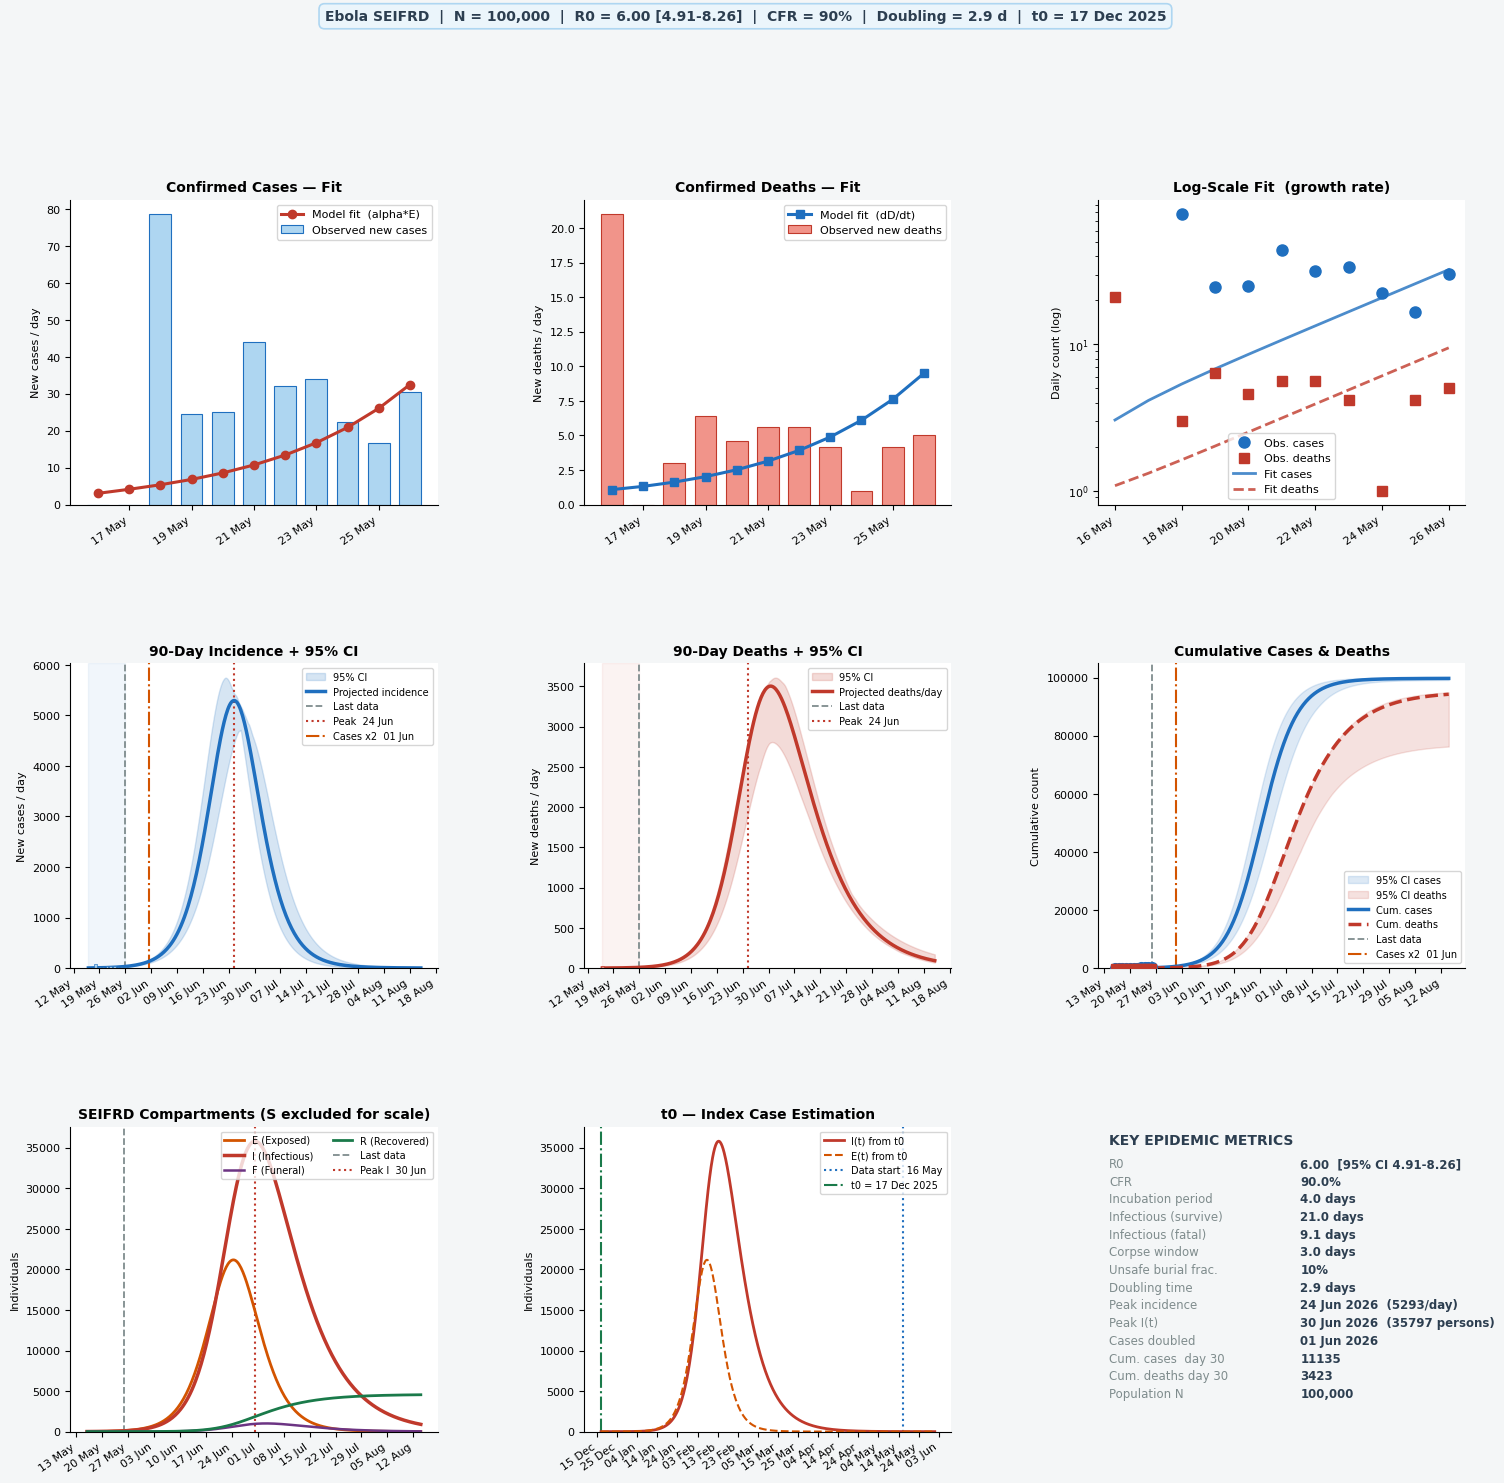


Figure saved -> /home/moez/ebola_calibration_final.png


In [34]:

# =====================================================================
# 12.  PLOTS
# =====================================================================

BLUE  = '#1F6FBF'; LBLUE  = '#AED6F1'
RED   = '#C0392B'; LRED   = '#F1948A'
GREEN = '#1A7A4A'; ORANGE = '#D35400'
GRAY  = '#7F8C8D'; PURPLE = '#6C3483'

def style(ax, interval=7):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=interval))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

def vl(ax, date, label, color, ls='--', lw=1.3):
    ax.axvline(date, color=color, lw=lw, ls=ls, label=label, zorder=1)

last_obs = obs_dates[-1]

fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor('#F4F6F7')
gs  = fig.add_gridspec(3, 3, hspace=0.52, wspace=0.40)

# [0,0]  CASES FIT
ax = fig.add_subplot(gs[0,0])
ax.bar(obs_dates, obs_cases, color=LBLUE, edgecolor=BLUE,
       lw=0.8, width=0.7, label='Observed new cases', zorder=2)
ax.plot(obs_dates, fit_cases, 'o-', color=RED, lw=2.2, ms=6,
        label='Model fit  (alpha*E)', zorder=3)
ax.set_title('Confirmed Cases — Fit', fontsize=10, fontweight='bold')
ax.set_ylabel('New cases / day', fontsize=8)
ax.legend(fontsize=8); ax.set_ylim(bottom=0)
style(ax, interval=2)

# [0,1]  DEATHS FIT
ax = fig.add_subplot(gs[0,1])
ax.bar(obs_dates, obs_deaths, color=LRED, edgecolor=RED,
       lw=0.8, width=0.7, label='Observed new deaths', zorder=2)
ax.plot(obs_dates, fit_deaths, 's-', color=BLUE, lw=2.2, ms=6,
        label='Model fit  (dD/dt)', zorder=3)
ax.set_title('Confirmed Deaths — Fit', fontsize=10, fontweight='bold')
ax.set_ylabel('New deaths / day', fontsize=8)
ax.legend(fontsize=8); ax.set_ylim(bottom=0)
style(ax, interval=2)

# [0,2]  LOG-SCALE FIT
ax = fig.add_subplot(gs[0,2])
mc = obs_cases > 0; md = obs_deaths > 0
ax.semilogy(np.array(obs_dates)[mc], obs_cases[mc],
            'o', color=BLUE, ms=8, label='Obs. cases', zorder=3)
ax.semilogy(np.array(obs_dates)[md], obs_deaths[md],
            's', color=RED,  ms=7, label='Obs. deaths', zorder=3)
ax.semilogy(obs_dates, np.maximum(fit_cases,  0.01),
            '-',  color=BLUE, lw=2, alpha=0.8, label='Fit cases')
ax.semilogy(obs_dates, np.maximum(fit_deaths, 0.001),
            '--', color=RED,  lw=2, alpha=0.8, label='Fit deaths')
ax.set_title('Log-Scale Fit  (growth rate)', fontsize=10, fontweight='bold')
ax.set_ylabel('Daily count (log)', fontsize=8)
ax.legend(fontsize=8)
style(ax, interval=2)

# [1,0]  INCIDENCE PROJECTION with CI
ax = fig.add_subplot(gs[1,0])
ax.axvspan(DATA_START, last_obs, alpha=0.06, color=BLUE)
ax.fill_between(pdates, inc_lo, inc_hi, color=BLUE, alpha=0.18, label='95% CI')
ax.plot(pdates, inc_p, '-', color=BLUE, lw=2.5, label='Projected incidence')
ax.bar(obs_dates, obs_cases, color=LBLUE, edgecolor=BLUE,
       lw=0.5, width=0.7, alpha=0.9, zorder=2)
vl(ax, last_obs,      'Last data',                       GRAY)
vl(ax, peak_inc_date, f'Peak  {peak_inc_date.strftime("%d %b")}', RED,  ':', 1.5)
if double_date:
    vl(ax, double_date, f'Cases x2  {double_date.strftime("%d %b")}', ORANGE, '-.', 1.5)
ax.set_title('90-Day Incidence + 95% CI', fontsize=10, fontweight='bold')
ax.set_ylabel('New cases / day', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax)

# [1,1]  DEATH PROJECTION with CI
ax = fig.add_subplot(gs[1,1])
ax.axvspan(DATA_START, last_obs, alpha=0.06, color=RED)
ax.fill_between(pdates, dead_lo, dead_hi, color=RED, alpha=0.18, label='95% CI')
ax.plot(pdates, dead_p, '-', color=RED, lw=2.5, label='Projected deaths/day')
ax.bar(obs_dates, obs_deaths, color=LRED, edgecolor=RED,
       lw=0.5, width=0.7, alpha=0.9, zorder=2)
vl(ax, last_obs,      'Last data',   GRAY)
vl(ax, peak_inc_date, f'Peak  {peak_inc_date.strftime("%d %b")}', RED, ':', 1.5)
ax.set_title('90-Day Deaths + 95% CI', fontsize=10, fontweight='bold')
ax.set_ylabel('New deaths / day', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax)

# [1,2]  CUMULATIVE with CI
ax = fig.add_subplot(gs[1,2])
ax.fill_between(pdates, cumC_lo, cumC_hi, color=BLUE, alpha=0.15, label='95% CI cases')
ax.fill_between(pdates, cumD_lo, cumD_hi, color=RED,  alpha=0.15, label='95% CI deaths')
ax.plot(pdates, cumC_p, '-',  color=BLUE, lw=2.5, label='Cum. cases')
ax.plot(pdates, cumD_p, '--', color=RED,  lw=2.5, label='Cum. deaths')
ax.plot(obs_dates, df["cum_confirmed"].values, 'o', color=BLUE, ms=7, zorder=3)
ax.plot(obs_dates, df["cum_conf_dead"].values, 's', color=RED,  ms=6, zorder=3)
vl(ax, last_obs, 'Last data', GRAY)
if double_date:
    vl(ax, double_date, f'Cases x2  {double_date.strftime("%d %b")}', ORANGE, '-.', 1.5)
ax.set_title('Cumulative Cases & Deaths', fontsize=10, fontweight='bold')
ax.set_ylabel('Cumulative count', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax)

# [2,0]  COMPARTMENTS (S excluded — too large to plot alongside others)
ax = fig.add_subplot(gs[2,0])
ax.plot(pdates, E_p, lw=2,   color=ORANGE, label='E (Exposed)')
ax.plot(pdates, I_p, lw=2.5, color=RED,    label='I (Infectious)')
ax.plot(pdates, F_p, lw=1.8, color=PURPLE, label='F (Funeral)')
ax.plot(pdates, R_p, lw=2,   color=GREEN,  label='R (Recovered)')
vl(ax, last_obs,    'Last data',                      GRAY)
vl(ax, peak_I_date, f'Peak I  {peak_I_date.strftime("%d %b")}', RED, ':', 1.5)
ax.set_title('SEIFRD Compartments (S excluded for scale)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Individuals', fontsize=8)
ax.legend(fontsize=7, ncol=2); ax.set_ylim(bottom=0)
style(ax)

# [2,1]  t0 TIMELINE
ax = fig.add_subplot(gs[2,1])
T_show   = int(np.ceil(days_before)) + n_days + 5
t_t0     = np.linspace(0, T_show, T_show*4+1)
sol_t0   = m.run((0, T_show), [N-1.,0.,1.,0.,0.,0.], t_t0)
t0_dates = [t0_date + timedelta(days=float(d)) for d in t_t0]
ax.plot(t0_dates, sol_t0.y[2], '-',  color=RED,    lw=2,   label='I(t) from t0')
ax.plot(t0_dates, sol_t0.y[1], '--', color=ORANGE, lw=1.5, label='E(t) from t0')
vl(ax, DATA_START, f'Data start  {DATA_START.strftime("%d %b")}', BLUE, ':', 1.5)
vl(ax, t0_date,    f't0 = {t0_date.strftime("%d %b %Y")}',        GREEN,'-.', 1.5)
ax.set_title('t0 — Index Case Estimation', fontsize=10, fontweight='bold')
ax.set_ylabel('Individuals', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax, interval=10)

# [2,2]  METRICS PANEL
ax = fig.add_subplot(gs[2,2])
ax.axis('off')
metrics = [
    ("R0",                   f"{R0:.2f}  [95% CI {R0_lo:.2f}-{R0_hi:.2f}]"),
    ("CFR",                  f"{delta1*100:.1f}%"),
    ("Incubation period",    f"{1/alpha:.1f} days"),
    ("Infectious (survive)", f"{1/gamma_i:.1f} days"),
    ("Infectious (fatal)",   f"{1/gamma_d:.1f} days"),
    ("Corpse window",        f"{1/gamma_f:.1f} days"),
    ("Unsafe burial frac.",  f"{teta1*100:.0f}%"),
    ("Doubling time",        f"{Td:.1f} days"),
    #("Index case t0",        t0_date.strftime('%d %b %Y')),
    ("Peak incidence",       f"{peak_inc_date.strftime('%d %b %Y')}  ({peak_inc_val:.0f}/day)"),
    ("Peak I(t)",            f"{peak_I_date.strftime('%d %b %Y')}  ({peak_I_val:.0f} persons)"),
    ("Cases doubled",        double_date.strftime('%d %b %Y') if double_date else "> 90 days"),
    ("Cum. cases  day 30",   f"{np.interp(30,t_fine,cumC_p):.0f}"),
    ("Cum. deaths day 30",   f"{np.interp(30,t_fine,cumD_p):.0f}"),
    ("Population N",         f"{N:,}"),
]
ax.text(0.03, 0.98, "KEY EPIDEMIC METRICS", transform=ax.transAxes,
        fontsize=10, fontweight='bold', color='#2C3E50', va='top')
y = 0.90
for label, value in metrics:
    ax.text(0.03, y, label,  transform=ax.transAxes,
            fontsize=8.5, color=GRAY,      va='top')
    ax.text(0.55, y, value,  transform=ax.transAxes,
            fontsize=8.5, color='#2C3E50', fontweight='bold', va='top')
    y -= 0.058

fig.text(
    0.5, 0.999,
    f"Ebola SEIFRD  |  N = {N:,}  |  R0 = {R0:.2f} [{R0_lo:.2f}-{R0_hi:.2f}]"
    f"  |  CFR = {delta1*100:.0f}%  |  Doubling = {Td:.1f} d"
    f"  |  t0 = {t0_date.strftime('%d %b %Y')}",
    ha='center', va='top', fontsize=10, fontweight='bold', color='#2C3E50',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB',
              edgecolor='#AED6F1', lw=1.2)
)

save_path = os.path.join(os.path.expanduser("~"), "ebola_calibration_final.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"\nFigure saved -> {save_path}")